Importing all nessesary libraries

In [45]:
import pandas as pd
import numpy as np 
import matplotlib.pyplot as plt 
import seaborn as sns

Uploading dataset

In [46]:
df = pd.read_csv('Fish.csv')

Let`s get familiar with our dataset

In [47]:
df.head()

,Species,Weight,Length1,Length2,Length3,Height,Width
0,Bream,242.0,23.2,25.4,30.0,11.5200,4.0200
1,Bream,290.0,24.0,26.3,31.2,12.4800,4.3056
2,Bream,340.0,23.9,26.5,31.1,12.3778,4.6961
3,Bream,363.0,26.3,29.0,33.5,12.7300,4.4555
4,Bream,430.0,26.5,29.0,34.0,12.4440,5.1340


##### Definition of every feature

**Species**: Species name of fish

**Weight**: Weight of fish in gram

**Length1**: Vertical length in cm

**Length2**: Diagonal length in cm

**Length3**: Cross length in cm

**Height**: Height in cm

**Width**: Diagonal width in cm

Checking for the missed values

In [48]:
df.isnull().sum()

Species    0
Weight     0
Length1    0
Length2    0
Length3    0
Height     0
Width      0
dtype: int64

Let`s vizualize the distribution of the target feature

In [49]:
df['Species'].value_counts()

Species
Perch        56
Bream        35
Roach        20
Pike         17
Smelt        14
Parkki       11
Whitefish     6
Name: count, dtype: int64

In oreder to see the linear dependencies we will visualize the correlation matrix

<Axes: >

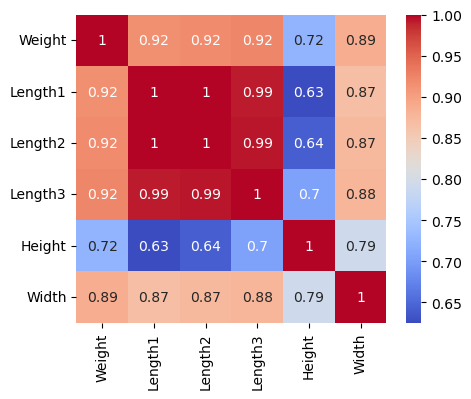

In [50]:
plt.figure(figsize=(5,4))
sns.heatmap(df.corr(numeric_only=True), annot=True, cmap="coolwarm")

We can see that all the leghts are dependent so we need to perform some feature engineering

In [51]:
df['Volume'] = df['Height']*df['Length3']*df['Length1']
df['Height/Width'] = df['Height']/df['Width']
df['Height/Lenthdia'] = df['Height']/df['Length2']

In [ ]:
df.drop('Length1', axis=1, inplace=True)
df.drop('Length3', axis=1, inplace=True)
df.drop('Weight', axis=1, inplace=True)
df.drop('Height', axis=1, inplace=True)

First thing first let`s decode oure target feature. We use labelencoder, becouse decision trees are not sensitive to scaling and they are not trying to fing math relationship such as between 0 and 2, that one is grater tha other, they are just trying to find the best split in the enery node

In [53]:
from sklearn.preprocessing import LabelEncoder
encoder = LabelEncoder()

In [54]:
df['Species'] = encoder.fit_transform(df['Species'])

Let`s see the distribution of every feature

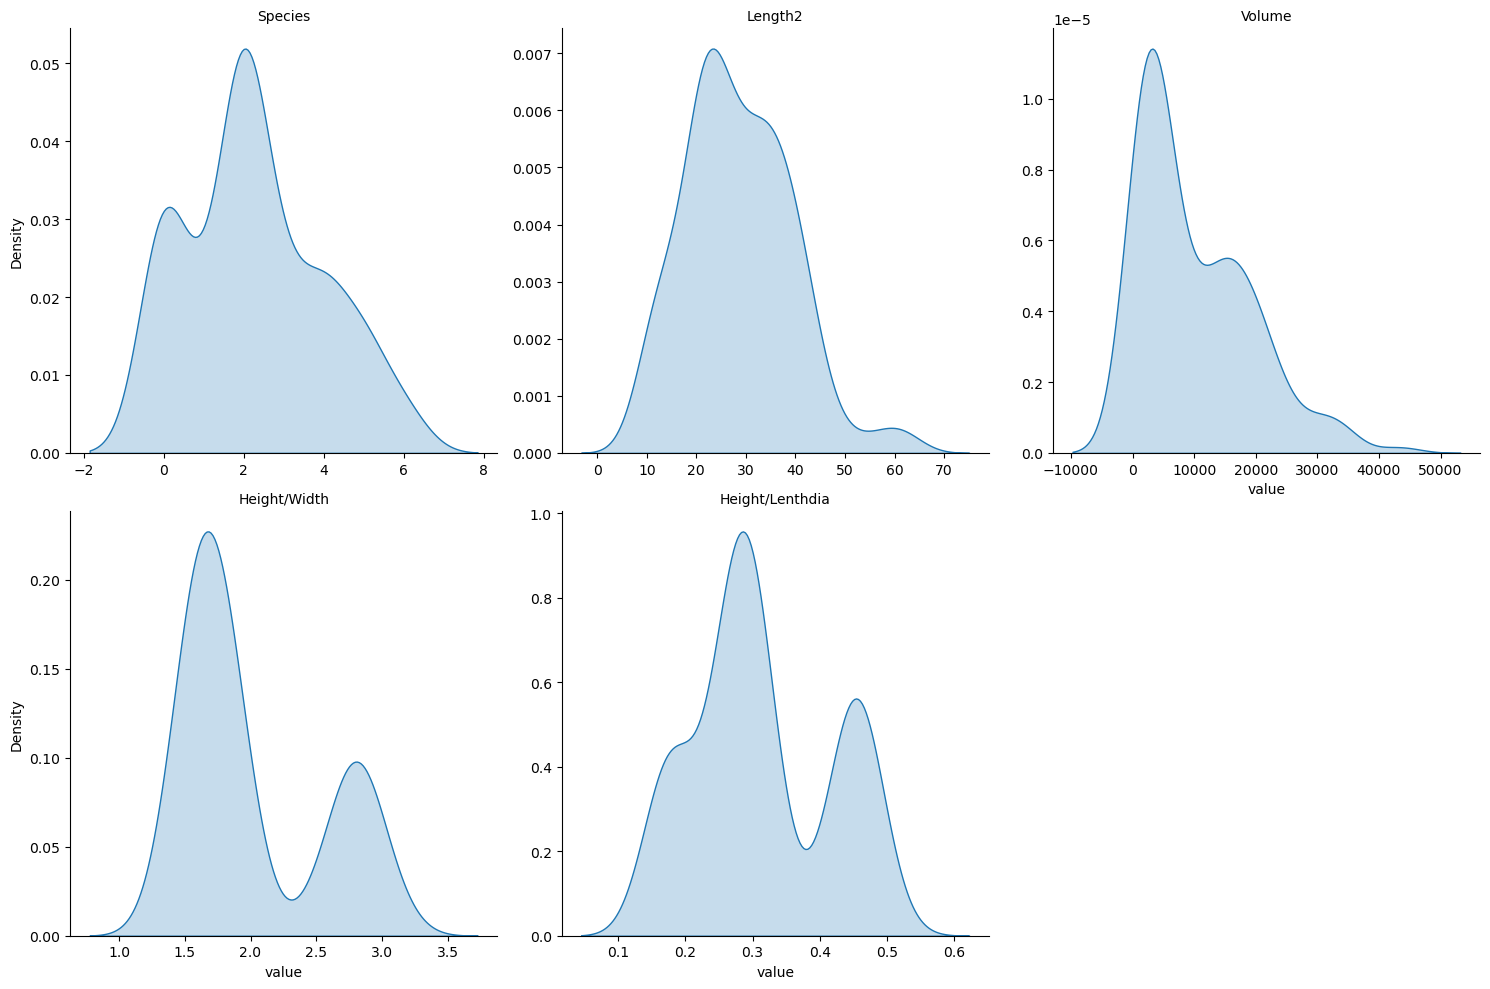

In [55]:
df_melted = df.melt()


g = sns.displot(
    data=df_melted, 
    x='value', 
    col='variable',
    kind='kde',
    col_wrap=3, 
    facet_kws={'sharex': False, 'sharey': False}, 
    fill=True
)

g.set_titles("{col_name}")
plt.show()

<Axes: >

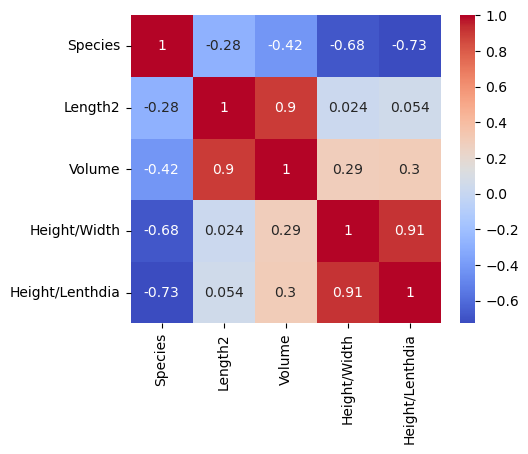

In [56]:
plt.figure(figsize=(5,4))
sns.heatmap(df.corr(numeric_only=True), annot=True, cmap="coolwarm")

In [57]:
X = df.drop('Species', axis = 1)
y = df['Species']

In [58]:
from sklearn.model_selection import train_test_split

In [85]:
X_train, X_test, y_trai, y_test = train_test_split(X, y, test_size=0.5, random_state=42)

In [86]:
from sklearn.ensemble import RandomForestClassifier

In [87]:
model = RandomForestClassifier(max_depth=8, n_estimators=100, oob_score=True,criterion='entropy', max_features='log2', class_weight='balanced')

In [88]:
model.fit(X_train, y_trai)

RandomForestClassifier(class_weight='balanced', criterion='entropy',
                       max_depth=8, max_features='log2', oob_score=True)

In [89]:
model.oob_score_

0.8481012658227848

In [90]:
from sklearn.model_selection import GridSearchCV

In [91]:
rf = RandomForestClassifier(random_state=42)
params = {
    "criterion": ["gini", "entropy"],
    'max_features':["log2","sqrt"],
    'max_depth': [2,3,4,5,6,7],
    'min_samples_leaf': [2,3,5,10,15,20,25,30,50,100],
    'n_estimators': [2,3,5,10,15,25,30,40,50, 100]
}

In [92]:
grid = GridSearchCV(estimator=rf,
                           param_grid=params,
                           cv = 4,
                           scoring="accuracy",
                           n_jobs=-1)

In [93]:
grid.fit(X_train, y_trai)

c:\Users\Julia\anaconda3\Lib\site-packages\sklearn\model_selection\_split.py:776: UserWarning: The least populated class in y has only 3 members, which is less than n_splits=4.
  warnings.warn(


GridSearchCV(cv=4, estimator=RandomForestClassifier(random_state=42), n_jobs=-1,
             param_grid={'criterion': ['gini', 'entropy'],
                         'max_depth': [2, 3, 4, 5, 6, 7],
                         'max_features': ['log2', 'sqrt'],
                         'min_samples_leaf': [2, 3, 5, 10, 15, 20, 25, 30, 50,
                                              100],
                         'n_estimators': [2, 3, 5, 10, 15, 25, 30, 40, 50,
                                          100]},
             scoring='accuracy')

In [94]:
grid.best_params_

{'criterion': 'gini',
 'max_depth': 3,
 'max_features': 'log2',
 'min_samples_leaf': 3,
 'n_estimators': 100}

In [95]:
grid.best_score_

0.8868421052631579

In [96]:
y_hat = grid.predict(X_test)

In [97]:
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

In [98]:
print(f"Accuracy на тесті: {accuracy_score(y_test, y_hat)}")
print(classification_report(y_test, y_hat))

Accuracy на тесті: 0.875
              precision    recall  f1-score   support

           0       1.00      0.95      0.98        22
           1       0.86      1.00      0.92         6
           2       0.83      0.93      0.88        27
           3       1.00      1.00      1.00         8
           4       0.43      0.43      0.43         7
           5       1.00      1.00      1.00         7
           6       0.00      0.00      0.00         3

    accuracy                           0.88        80
   macro avg       0.73      0.76      0.74        80
weighted avg       0.85      0.88      0.86        80



c:\Users\Julia\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
c:\Users\Julia\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
c:\Users\Julia\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
